--- Eğitim ve Test Doğruluk Tablosu ---


,Eğitim,Test
Model,,
Baseline,0.518,0.518
Logistic,1.000,0.998
KNN,1.000,1.000
Karar ağacı,1.000,1.000
Rastgele orman,1.000,1.000


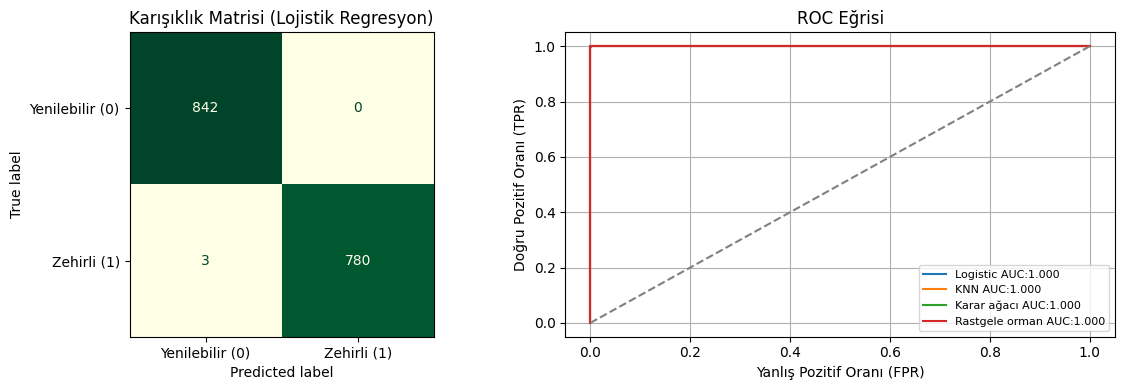

--- 5-Fold Çapraz Doğrulama Sonuçları ---


,Ortalama skor,Standart sapma
Model,,
Rastgele orman,1.000,0.000
Karar ağacı,1.000,0.001
KNN,0.999,0.001
Logistic,0.999,0.001
Baseline,0.518,0.000



--- KNN GridSearchCV Sonuçları ---
best parametre: {'kneighborsclassifier__n_neighbors': 1, 'kneighborsclassifier__weights': 'uniform'}
en iyi cv skoru: 1.000


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

SEED = 42

# 1. Veri Setini UCI Deposundan Yükleme (Mushroom Dataset)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
df = pd.read_csv(url, header=None)

# 2. Ön İşleme
# İlk sütun hedef değişkendir ('p': poisonous, 'e': edible)
y_raw = df.iloc[:, 0]
X_raw = df.iloc[:, 1:]

# Eksik değer içeren '?' karakterlerini yönetme
X_raw = X_raw.replace('?', np.nan)
# Eksik sütun varsa doldur veya temizle (çoğu zaman 'veil-type' gibi tekil değer içerenler de düşürülebilir)
X_raw = X_raw.fillna(X_raw.mode().iloc[0])

# Hedef değişkeni ikili (0: edible/iyi, 1: poisonous/habis) hale getirme
le = LabelEncoder()
y_clf = le.fit_transform(y_raw)  # e -> 0, p -> 1

# Kategorik özellikleri One-Hot Encoding ile sayısallaştırma
X_clf = pd.get_dummies(X_raw, drop_first=True)

# 3. Train-Test Ayrımı
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf
)

# 4. Modelleri Tanımlama ve Eğitme
siniflandiricilar = {
    "Baseline": DummyClassifier(strategy="most_frequent").fit(Xc_train, yc_train),
    "Logistic": LogisticRegression(max_iter=1000).fit(Xc_train, yc_train),
    "KNN": KNeighborsClassifier().fit(Xc_train, yc_train),
    "Karar ağacı": DecisionTreeClassifier(random_state=SEED).fit(Xc_train, yc_train),
    "Rastgele orman": RandomForestClassifier(random_state=SEED).fit(Xc_train, yc_train)
}

# 5. Eğitim ve Test Başarı Tablosu
satirlar = []
for ad, m in siniflandiricilar.items():
    satirlar.append({
        "Model": ad,
        "Eğitim": accuracy_score(yc_train, m.predict(Xc_train)),
        "Test": accuracy_score(yc_test, m.predict(Xc_test))
    })

print("--- Eğitim ve Test Doğruluk Tablosu ---")
display(pd.DataFrame(satirlar).set_index("Model").round(3))

# 6. Karışıklık Matrisi ve ROC Eğrileri
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Lojistik Regresyon için Karışıklık Matrisi
model = siniflandiricilar["Logistic"]
tahmin = model.predict(Xc_test)

ConfusionMatrixDisplay.from_predictions(
    yc_test, tahmin,
    display_labels=["Yenilebilir (0)", "Zehirli (1)"],
    cmap="YlGn",
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Karışıklık Matrisi (Lojistik Regresyon)")
axes[0].grid(False)

# ROC Eğrisi Karşılaştırması
for ad in ["Logistic", "KNN", "Karar ağacı", "Rastgele orman"]:
    p = siniflandiricilar[ad].predict_proba(Xc_test)[:, 1]
    fpr, tpr, _ = roc_curve(yc_test, p)
    axes[1].plot(fpr, tpr, label=f"{ad} AUC:{roc_auc_score(yc_test, p):.3f}")

axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("Yanlış Pozitif Oranı (FPR)")
axes[1].set_ylabel("Doğru Pozitif Oranı (TPR)")
axes[1].set_title("ROC Eğrisi")
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 7. Stratified K-Fold Çapraz Doğrulama
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_satirlar = []

for ad, m in siniflandiricilar.items():
    skorlar = cross_val_score(m, Xc_train, yc_train, cv=cv, scoring="accuracy")
    cv_satirlar.append({
        "Model": ad,
        "Ortalama skor": skorlar.mean(),
        "Standart sapma": skorlar.std()
    })

print("--- 5-Fold Çapraz Doğrulama Sonuçları ---")
cv_sonuc = pd.DataFrame(cv_satirlar).set_index("Model").sort_values("Ortalama skor", ascending=False).round(3)
display(cv_sonuc)

# 8. KNN Hiperparametre Optimizasyonu (GridSearchCV)
pipe = make_pipeline(StandardScaler(with_mean=False), KNeighborsClassifier())

param_grid = {
    "kneighborsclassifier__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
    "kneighborsclassifier__weights": ["uniform", "distance"]
}

opt = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
opt.fit(Xc_train, yc_train)

print("\n--- KNN GridSearchCV Sonuçları ---")
print("best parametre:", opt.best_params_)
print(f"en iyi cv skoru: {opt.best_score_:.3f}")